In [51]:
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
import statsmodels.api as sm
import matplotlib.pyplot as plt



In [5]:
df = pd.read_csv("employee_training.csv")
print("shape: " +  str(df.shape))
df.head(5)


shape: (90, 20)


,employee_id,employee_first_name,employee_last_name,employee_email,department,job_title,training_id,training_title,training_type,training_start_date,training_end_date,training_location,trainer_name,participation_status,completion_score,feedback_rating,feedback_comments,is_mandatory,certification_awarded,certification_expiry_date
0,E1021,Sophia,Nguyen,sophia.nguyen@company.com,Finance,Financial Analyst,TRN-202401,Cybersecurity Compliance 2024,compliance,2024-01-12,2024-01-12,Virtual,Alex Chen,completed,94.5,4.8,Very informative and well-structured session.,True,True,2026-01-12
1,E1033,Michael,Williams,m.williams@company.com,IT,Systems Engineer,TRN-202401,Cybersecurity Compliance 2024,compliance,2024-01-12,2024-01-12,Virtual,Alex Chen,completed,89.0,4.2,"Clear explanations, useful examples.",True,True,2026-01-12
2,E1047,Priya,Rao,priya.rao@company.com,Marketing,Marketing Specialist,TRN-202401,Cybersecurity Compliance 2024,compliance,2024-01-12,2024-01-12,Virtual,Alex Chen,attended,NaN,NaN,NaN,True,False,NaN
3,E1082,Jacob,Smith,jacob.smith@company.com,Sales,Account Manager,TRN-202402,Advanced Sales Techniques,soft skills,2024-02-03,2024-02-04,New York HQ,Rachel Lee,completed,87.0,4.5,"Practical strategies, engaging exercises.",False,False,NaN
4,E1122,Ava,Johnson,ava.johnson@company.com,Sales,Sales Associate,TRN-202402,Advanced Sales Techniques,soft skills,2024-02-03,2024-02-04,New York HQ,Rachel Lee,missed,NaN,NaN,NaN,False,False,NaN


In [52]:
date_cols = [
    "training_start_date",
    "training_end_date",
    "certification_expiry_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df["completed_binary"] = df["participation_status"] == "completed"

df["participation_status"].value_counts()

participation_status
completed     58
attended      19
registered     6
missed         4
incomplete     3
Name: count, dtype: int64

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   employee_id                90 non-null     object        
 1   employee_first_name        90 non-null     object        
 2   employee_last_name         90 non-null     object        
 3   employee_email             90 non-null     object        
 4   department                 90 non-null     object        
 5   job_title                  90 non-null     object        
 6   training_id                90 non-null     object        
 7   training_title             90 non-null     object        
 8   training_type              90 non-null     object        
 9   training_start_date        90 non-null     datetime64[ns]
 10  training_end_date          90 non-null     datetime64[ns]
 11  training_location          90 non-null     object        
 12  trainer_na

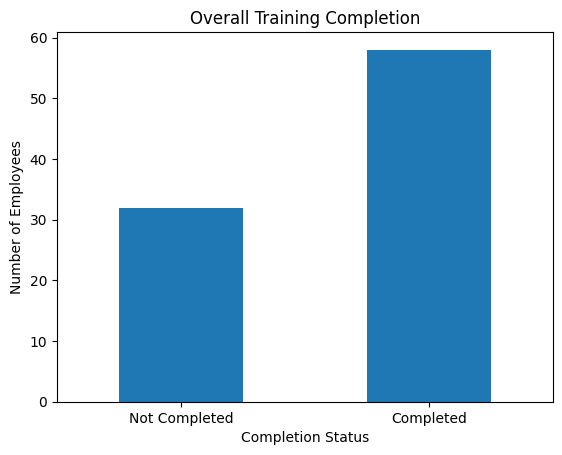

In [53]:
# -----------------------------
# 1. Overall Completion Rate
# -----------------------------
plt.figure()
completion_counts = df["completed_binary"].value_counts().sort_index()
completion_counts.index = ["Not Completed", "Completed"]
completion_counts.plot(kind="bar")
plt.title("Overall Training Completion")
plt.ylabel("Number of Employees")
plt.xlabel("Completion Status")
plt.xticks(rotation=0)
plt.show()

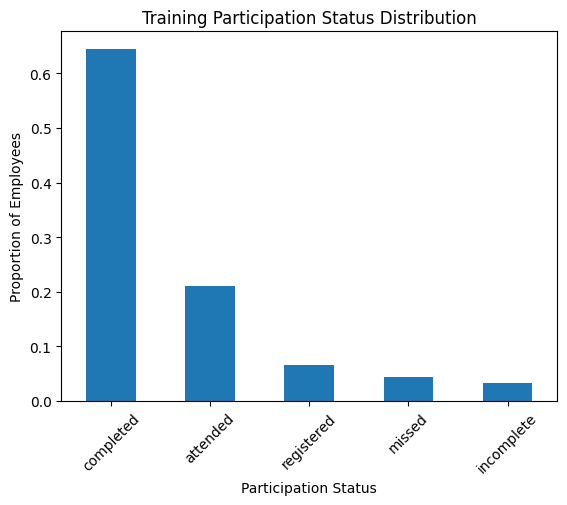

In [57]:
plt.figure()

status_counts = df["participation_status"].value_counts(normalize=True)
status_counts = status_counts.sort_values(ascending=False)

status_counts.plot(kind="bar")

plt.title("Training Participation Status Distribution")
plt.ylabel("Proportion of Employees")
plt.xlabel("Participation Status")
plt.xticks(rotation=45)
plt.show()

In [17]:
pd.crosstab(
    df["participation_status"],
    df["completion_score"].isnull()
)

completion_score,False,True
participation_status,,
attended,0,19
completed,58,0
incomplete,0,3
missed,0,4
registered,0,6


participation_status
completed     0.644444
attended      0.211111
registered    0.066667
missed        0.044444
incomplete    0.033333
Name: proportion, dtype: float64

In [19]:
pd.crosstab(
    df["is_mandatory"],
    df["participation_status"],
    normalize="index"
)


participation_status,attended,completed,incomplete,missed,registered
is_mandatory,,,,,
False,0.187500,0.625000,0.0625,0.041667,0.083333
True,0.238095,0.666667,0.0000,0.047619,0.047619


In [20]:
df["completion_days"] = (
    df["training_end_date"] - df["training_start_date"]
).dt.days

In [21]:
df["completion_days"].describe()

count    90.000000
mean      0.544444
std       0.621002
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       2.000000
Name: completion_days, dtype: float64

In [22]:
df.groupby("department")["completion_days"].mean()


department
Customer Service      0.000000
Finance               0.500000
HR                    0.090909
IT                    1.125000
Legal                 0.000000
Logistics             1.000000
Marketing             0.900000
Operations            0.333333
Product Management    1.000000
R&D                   0.000000
Sales                 0.700000
Name: completion_days, dtype: float64

In [23]:
df["completion_score"].describe()


count    58.000000
mean     85.856897
std       5.546838
min      75.100000
25%      81.100000
50%      85.950000
75%      90.000000
max      96.700000
Name: completion_score, dtype: float64

In [24]:
df.groupby("training_type")["completion_score"].mean()


training_type
compliance     89.693333
leadership     81.600000
other          85.400000
soft skills    81.158824
technical      87.680000
Name: completion_score, dtype: float64

In [25]:
df.groupby("trainer_name")["feedback_rating"].mean().sort_values()


trainer_name
Diana Stone         3.875000
Ana Silva           3.900000
Liam Torres         3.966667
Rachel Lee          3.975000
Jean Dubois         3.975000
Marco Conti         4.033333
Lena Schneider      4.033333
Maria Santos        4.050000
Carlos Ruiz         4.080000
Erik Johansson      4.150000
Wei Li              4.200000
Sophie Müller       4.233333
Kurt Bauer          4.400000
Samuel Price        4.425000
Brian Foster        4.500000
Nina Larsen         4.525000
Nina Brown          4.533333
Tobias Keller       4.600000
Kasia Zielinska     4.600000
Philip White        4.600000
Jasmine Patel       4.625000
Alex Chen           4.633333
Oliver Fischer      4.650000
Claire Delacroix    4.900000
Pieter Bakker            NaN
Name: feedback_rating, dtype: float64

In [27]:
contingency = pd.crosstab(
    df["is_mandatory"],
    df["participation_status"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 3.403389940368161
p-value: 0.49271930536446795


In [29]:
df["completed_binary"] = df["participation_status"] == "completed"

contingency = pd.crosstab(
    df["department"],
    df["completed_binary"]
)

chi2, p, dof, expected = chi2_contingency(contingency)
print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 6.2570410462382435
p-value: 0.7932251991626275


In [31]:
mandatory_scores = df[df["is_mandatory"]]["completion_score"].dropna()
optional_scores = df[~df["is_mandatory"]]["completion_score"].dropna()

t_stat, p = ttest_ind(mandatory_scores, optional_scores)

print("p-value:", p)

p-value: 0.0010557172754718665


The t-test yielded a p-value of 0.001, indicating strong statistical evidence that the average completion scores differed between the two groups. This suggests the difference is unlikely due to random variation

In [33]:
groups = [
    group["completion_score"].dropna()
    for name, group in df.groupby("training_type")
]

f_stat, p = f_oneway(*groups)

print("p-value:", p)

p-value: 1.043457404800262e-05


In [35]:
df["completion_days"] = (
    df["training_end_date"] - df["training_start_date"]
).dt.days

df[["completion_days", "completion_score"]].corr()


,completion_days,completion_score
completion_days,1.000000,0.107494
completion_score,0.107494,1.000000


In [39]:
df["completed_binary"] = (df["participation_status"] == "completed").astype(int)

X = df[["is_mandatory"]].astype(int)
X = sm.add_constant(X)

y = df["completed_binary"].astype(int)

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.649874
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:       completed_binary   No. Observations:                   90
Model:                          Logit   Df Residuals:                       88
Method:                           MLE   Df Model:                            1
Date:                Tue, 17 Feb 2026   Pseudo R-squ.:                0.001451
Time:                        22:28:49   Log-Likelihood:                -58.489
converged:                       True   LL-Null:                       -58.574
Covariance Type:            nonrobust   LLR p-value:                    0.6801
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.5108      0.298      1.713      0.087      -0.074       1.095
is_mandatory     0.1823

In [43]:
pd.crosstab(df["training_type"], df["completed_binary"], normalize="index")

completed_binary,0,1
training_type,,
compliance,0.347826,0.652174
leadership,0.250000,0.750000
other,0.250000,0.750000
soft skills,0.370370,0.629630
technical,0.375000,0.625000


In [46]:
chi2_contingency(pd.crosstab(df["training_type"], df["completed_binary"]))


Chi2ContingencyResult(statistic=0.47366941529235373, pvalue=0.9760131232247738, dof=4, expected_freq=array([[ 8.17777778, 14.82222222],
       [ 1.42222222,  2.57777778],
       [ 1.42222222,  2.57777778],
       [ 9.6       , 17.4       ],
       [11.37777778, 20.62222222]]))

In [47]:
pd.crosstab(df["training_location"], df["completed_binary"], normalize="index")

completed_binary,0,1
training_location,,
Amsterdam Office,1.000000,0.000000
Berlin HQ,0.250000,0.750000
Chicago,0.500000,0.500000
Copenhagen Lab,0.250000,0.750000
Hamburg Warehouse,0.500000,0.500000
Lisbon Branch,0.333333,0.666667
London Data Center,0.000000,1.000000
Madrid Office,0.200000,0.800000
Milan HQ,0.333333,0.666667


In [49]:
df["training_format"] = df["training_location"].apply(
    lambda x: "Virtual" if "Virtual" in x or "Remote" in x else "In-Person"
)

pd.crosstab(df["training_format"], df["completed_binary"], normalize="index")

completed_binary,0,1
training_format,,
In-Person,0.351852,0.648148
Virtual,0.361111,0.638889


In [50]:
contingency = pd.crosstab(df["training_format"], df["completed_binary"])
chi2_contingency(contingency)

Chi2ContingencyResult(statistic=0.0, pvalue=1.0, dof=1, expected_freq=array([[19.2, 34.8],
       [12.8, 23.2]]))